# Tutorials

Here we present examples on how MieAI can be used.


## Grid interpolation

If opacity calculations have to be quick but no AI model is available, Grid interpolation provides a useful alternative. In contrast to AI models, grids are readily created, but take up more storage and are less accurate. Here we show the three steps of grid interpolation.

### Step 1: Creating a grid

To create a grid three things are required:
- wavelength range: Ideally, this should be tailored to your need. A smaller wavelength range helps to reduce the storage space and increases the accuracy.
- cloud particle size range: The default grid is ideal for most applications. However, if you would like higher accuracy you can increase the number of cloud particle radii considered.
- Number of volume mixing ratios: This value determines the accuracy in the mixing between materials and is inverse to the steps in mixing percentage. A value of 20 will result in a 5% accuracy.

The total number of datapoints calculated is equal to (number of wavelengths) * (number of radii) * (number of VMRs)^(number of species - 1). Reducing the number of VMRs is therefore the best way to minimize storage and computation time if more than 2 species are considered. Giving a save file name will save the grid as xarray.Dataset which can later be re-loaded into MieAi. The file name should start with 'grid_' and end with '.nc' to be automatically recognized by Mieai. Producing the grid is done with the following MieAi function:

In [1]:
import numpy as np
from mienet import Mieai

# import mie ai
ma = Mieai(use_ai=False, mute=False)

# determine grid parameters
species = ['Fe', 'SiO2', 'TiO2']
wavelength_range = np.logspace(0, 1, 200)  # Infrared for cloud feature studies
radius_range = np.logspace(-4, 3.1, 100)  # This is the default value
vmr_points = 3  # This is a low value for the tutorial, 20 or higher is recommended

# calculate grid
ds = ma.produce_efficiency_grid(
    species, wavelengths=wavelength_range,
    particle_sizes=radius_range, vmr_data_points=vmr_points,
    save_file='tutorial_files/grid_tutorial.nc'
)

[INFO] Calculating mie efficiency grid
   -> Wavelengths: 1.0 to 10.0 microns
   -> Particle sizes: 0.0001 to 1258.9254117941675 microns
   -> VMR spacing: 50.0%
[INFO] Starting grid calculation ...
   -> Progress: 0.0% (ETA: --)
   -> Progress: 11.1% (ETA: 2026-05-22 21:02:44)
   -> Progress: 22.2% (ETA: 2026-05-22 21:02:46)
   -> Progress: 33.3% (ETA: 2026-05-22 21:02:42)
   -> Progress: 44.4% (ETA: 2026-05-22 21:02:45)
   -> Progress: 55.6% (ETA: 2026-05-22 21:02:45)
   -> Progress: 66.7% (ETA: 2026-05-22 21:02:45)
   -> Progress: 77.8% (ETA: 2026-05-22 21:02:46)
   -> Progress: 88.9% (ETA: 2026-05-22 21:02:46)
[INFO] Grid saved as: tutorial_files/grid_tutorial.nc
[INFO] Grid calculation complete


### Step 2: Load Grid into MieAI

The easiest way to load grids into MieAI is by naming them 'grid_YOURNAME.nc' and storing them in the data folder of MieAI. This way, they will be automatically loaded whenever you initialise the MieAI class. You can also manually load data grids, using the following MieAI functions:

In [2]:
# load grid from file
ma.load_grid_efficiency(file_name='tutorial_files/grid_tutorial.nc')

# load grid from dataset
ma.load_grid_efficiency(ds_grid=ds, ds_grid_name='test_grid')

[INFO] Added grid for ['Fe', 'SiO2', 'TiO2'] from 1.0 to 10.0 micron.


### Step 3: You are ready to use grid interpolation

Now you are ready to use the grid interpolation fucntion of MieAi!

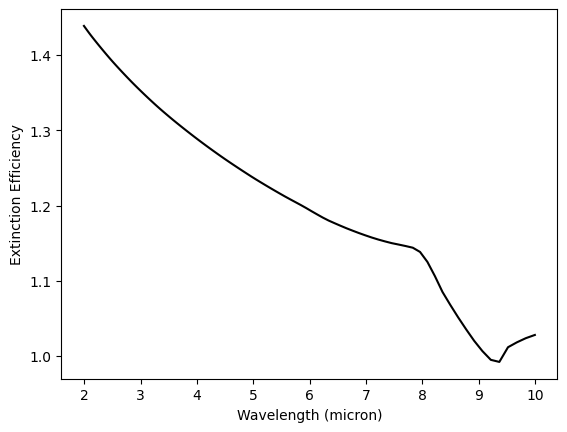

In [5]:
import matplotlib.pyplot as plt

# determine grid parameters
species = ['Fe', 'SiO2', 'TiO2']
wavelength_range = np.logspace(0.3, 1, 100)  # Infrared for cloud feature studies
radius_range = np.logspace(-3, 2, 100)  # This is the default value
vmrs = {
    'Fe': 0.2 * np.ones_like(radius_range),
    'SiO2': 0.5 * np.ones_like(radius_range),
    'TiO2': 0.3 * np.ones_like(radius_range),
}

# get efficiencies from grid interpolation
qext, qsca, asym = ma.grid_efficiencies(wavelength_range, radius_range, vmrs)

# plot results
plt.figure()
plt.plot(wavelength_range, np.mean(qext, axis=0), 'k')
plt.xlabel('Wavelength (micron)')
plt.ylabel('Extinction Efficiency')
plt.show()

To increase the accuracy of the grid interpolation, the number of VMR and wavelength data points can be increased. However, both lead to large grid files and it might take a long time to create the datasets.